<a href="https://colab.research.google.com/github/patriciaruizpaz/clinical-deterioration-intelligence/blob/main/notebooks/02_analisis_estadistico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# ============================================
# CELDA 1 — Montar Drive
# ============================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# ============================================
# CELDA 2 — Configurar git y clonar el repo (limpio, sin duplicar carpetas)
# ============================================
from getpass import getpass
import os

TOKEN = getpass("Pegá tu token de GitHub: ")

!git config --global user.email "patricia.megi@gmail.com"
!git config --global user.name "patriciaruizpaz"

if os.path.exists('/content/clinical-deterioration-intelligence'):
    !rm -rf /content/clinical-deterioration-intelligence

%cd /content
!git clone https://{TOKEN}@github.com/patriciaruizpaz/clinical-deterioration-intelligence.git
%cd clinical-deterioration-intelligence
!pwd

Pegá tu token de GitHub: ··········
/content
Cloning into 'clinical-deterioration-intelligence'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (39/39), done.
remote: Total 51 (delta 16), reused 42 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 13.15 MiB | 13.02 MiB/s, done.
Resolving deltas: 100% (16/16), done.
/content/clinical-deterioration-intelligence
/content/clinical-deterioration-intelligence


In [9]:
# ============================================
# CELDA 3 — Bloque 1 - Fase 4: reproducibilidad y setup técnico
# ============================================
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
random.seed(42)
sns.set_theme(style="whitegrid")

print("Setup completo ✅")

Setup completo ✅


In [12]:
# ============================================
# CELDA 4 — Leer el dataset ya limpio y con target (Fase 9 en adelante)
# ============================================
ruta_processed = '/content/drive/MyDrive/Portfolio_Datos/clinical-deterioration-intelligence/data/processed/'

panel = pd.read_csv(ruta_processed + 'panel_con_target.csv')

print(panel.shape)
print(panel['deterioration_next_12h'].value_counts(normalize=True).round(4) * 100)

(416635, 28)
deterioration_next_12h
0    94.61
1     5.39
Name: proportion, dtype: float64


In [13]:
# Actualizar el glosario de métricas con el resultado validado (Fase 3b → confirmado)
with open('docs/glosario_metricas.md', 'a') as f:
    f.write("""
## Validación — Tasa de deterioro a 12h (confirmado en Fase 9)
Resultado real sobre panel_con_target.csv (416.635 filas horarias):
- No deteriora en las próximas 12h: 94.61%
- Deteriora en las próximas 12h: 5.39%

Fuente: columna deterioration_next_12h de hospital_deterioration_hourly_panel.csv,
unida al panel limpio por (patient_id, hour_from_admission).
""")

!git add docs/glosario_metricas.md
!git commit -m "docs: valida tasa de deterioro a 12h con dato real (5.39%)"
!git push origin main

[main 286afdd] docs: valida tasa de deterioro a 12h con dato real (5.39%)
 1 file changed, 8 insertions(+)
Enumerating objects: 7, done.
Counting objects: 100% (7/7), done.
Delta compression using up to 2 threads
Compressing objects: 100% (4/4), done.
Writing objects: 100% (4/4), 634 bytes | 634.00 KiB/s, done.
Total 4 (delta 3), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (3/3), completed with 3 local objects.
To https://github.com/patriciaruizpaz/clinical-deterioration-intelligence.git
   b57e042..286afdd  main -> main


## Fase 9 — Backlog y orden estratégico

Ya resuelta en la Fase 1 (tabla de trazabilidad). Orden confirmado para este notebook:
1. Pregunta 1 — línea base (tasa de deterioro + diferencias en signos vitales)
2. Pregunta 2 — regresión logística (necesita la Pregunta 1 resuelta para interpretar
   los odds ratio con criterio clínico)

## Fase 10 — Marco de decisión estadística

| Decisión | Resuelto en | Resultado |
|---|---|---|
| ¿Las variables son normales? | Fase 8 (Shapiro-Wilk) | No — ninguna lo es (p<0.000001 en todas) |
| ¿Qué test se usa para comparar grupos? | → | U de Mann-Whitney (no paramétrico), no t de Student |
| ¿Las observaciones son independientes? | Fase 2 | No del todo — pseudo-replicación por paciente (cada paciente aporta varias filas horarias) |
| ¿Qué se hace con eso en la v1? | → | Se documenta como limitación conocida. Mann-Whitney a nivel hora es el enfoque práctico de esta versión; un GLMM sería la solución correcta pero queda fuera de alcance |

## Fase 11 — Pregunta 1: Riesgo clínico basal

**Definición del target usado:** `deterioration_next_12h` a nivel hora (no `deterioration_event`
a nivel paciente) — compara horas-observación que preceden un deterioro en las próximas 12h
contra las que no, sin importar de qué paciente provienen.

In [14]:
# Fase 11 — Pregunta 1, Paso 1: estadística descriptiva por grupo
variables_clave = ['spo2_pct', 'respiratory_rate', 'heart_rate', 'lactate']

comparacion = panel.groupby('deterioration_next_12h')[variables_clave].agg(['mean', 'median', 'std']).round(2)
print(comparacion)

                       spo2_pct              respiratory_rate               \
                           mean median   std             mean median   std   
deterioration_next_12h                                                       
0                         93.62  94.99  6.05            20.08  19.15  6.95   
1                         91.62  91.96  3.34            21.90  21.94  4.35   

                       heart_rate               lactate               
                             mean median    std    mean median   std  
deterioration_next_12h                                                
0                           88.98  85.87  21.47    1.96   1.58  1.54  
1                           94.17  94.37  13.19    2.51   2.36  0.89  


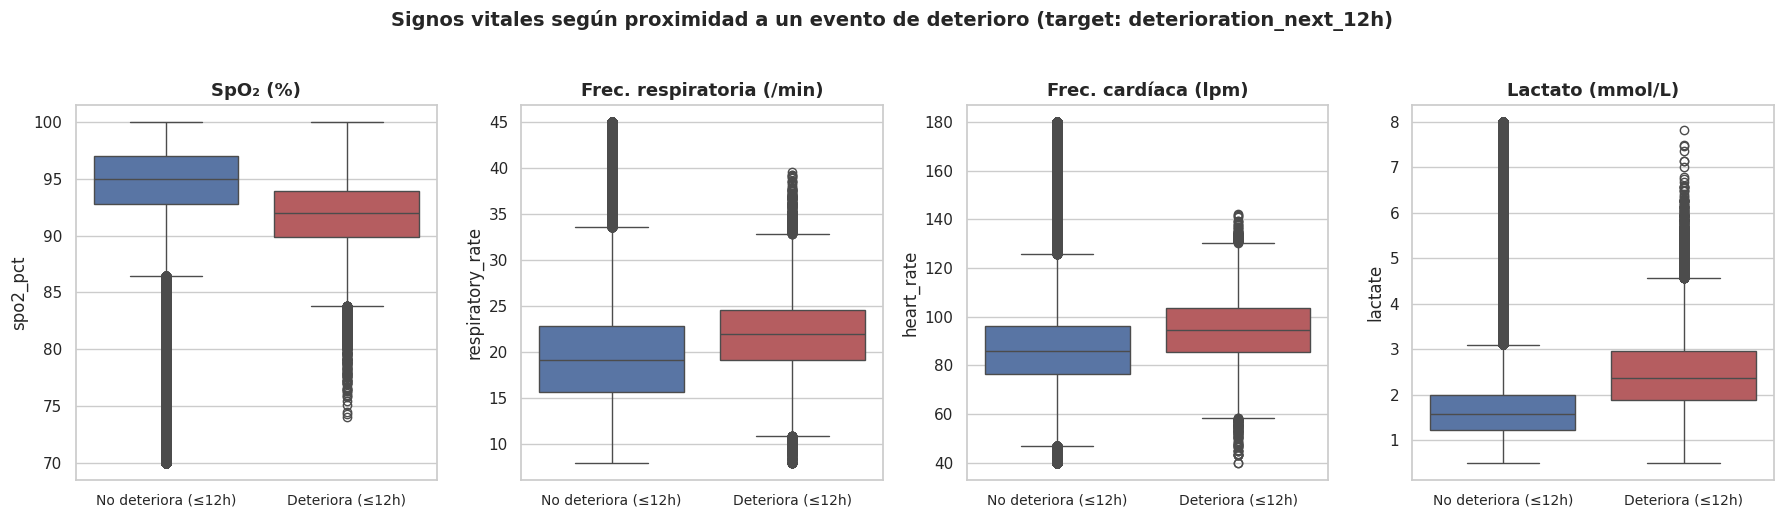

In [16]:
# Fase 11 — Pregunta 1, Paso 2: boxplots por grupo
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
titulos = ['SpO₂ (%)', 'Frec. respiratoria (/min)', 'Frec. cardíaca (lpm)', 'Lactato (mmol/L)']

for ax, col, titulo in zip(axes, variables_clave, titulos):
    sns.boxplot(data=panel, x='deterioration_next_12h', y=col, hue='deterioration_next_12h',
                palette=['#4C72B0', '#C44E52'], legend=False, ax=ax)
    ax.set_title(titulo, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['No deteriora (≤12h)', 'Deteriora (≤12h)'], fontsize=10)

plt.suptitle('Signos vitales según proximidad a un evento de deterioro (target: deterioration_next_12h)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('boxplot_pregunta1.png', dpi=200, bbox_inches='tight')
plt.show()

In [17]:
# Fase 11 — Pregunta 1, Paso 3: prueba U de Mann-Whitney
from scipy import stats

grupo_0 = panel[panel['deterioration_next_12h'] == 0]
grupo_1 = panel[panel['deterioration_next_12h'] == 1]

print("Prueba U de Mann-Whitney — grupo 'no deteriora' vs 'deteriora en ≤12h'\n")

for col in variables_clave:
    stat, p_valor = stats.mannwhitneyu(grupo_0[col], grupo_1[col], alternative='two-sided')
    significativo = "✅ significativo" if p_valor < 0.05 else "❌ no significativo"
    print(f"{col:20s} U={stat:,.0f}   p-valor={p_valor:.2e}   {significativo}")

Prueba U de Mann-Whitney — grupo 'no deteriora' vs 'deteriora en ≤12h'

spo2_pct             U=6,496,657,262   p-valor=0.00e+00   ✅ significativo
respiratory_rate     U=3,165,381,034   p-valor=0.00e+00   ✅ significativo
heart_rate           U=3,130,774,616   p-valor=0.00e+00   ✅ significativo
lactate              U=2,004,610,099   p-valor=0.00e+00   ✅ significativo


In [18]:
# Fase 11 — Pregunta 1, Paso 4: tamaño del efecto (rank-biserial correlation)
n0 = len(grupo_0)
n1 = len(grupo_1)

print("Tamaño del efecto (correlación rank-biserial)\n")

for col in variables_clave:
    stat, p_valor = stats.mannwhitneyu(grupo_0[col], grupo_1[col], alternative='two-sided')
    # r = 1 - (2U) / (n0 * n1)
    r = 1 - (2 * stat) / (n0 * n1)

    if abs(r) < 0.1:
        magnitud = "trivial"
    elif abs(r) < 0.3:
        magnitud = "pequeño"
    elif abs(r) < 0.5:
        magnitud = "moderado"
    else:
        magnitud = "grande"

    print(f"{col:20s} r={r:.3f}   ({magnitud})")

Tamaño del efecto (correlación rank-biserial)

spo2_pct             r=-0.467   (moderado)
respiratory_rate     r=0.285   (pequeño)
heart_rate           r=0.293   (pequeño)
lactate              r=0.547   (grande)


## Fase 11 — Pregunta 1: Conclusión

**Test usado:** U de Mann-Whitney (no paramétrico, justificado en Fase 10).
**Resultado:** las 4 variables muestran diferencia estadísticamente significativa
(p < 0.001) entre horas que preceden un deterioro en ≤12h y las que no.

**Tamaño del efecto (rank-biserial):**
- Lactato: r=0.547 (grande) — la señal más fuerte
- SpO₂: r=-0.467 (moderado)
- Frecuencia cardíaca: r=0.293 (pequeño)
- Frecuencia respiratoria: r=0.285 (pequeño)

**Conclusión clínica:** el lactato es el predictor individual más fuerte de los
signos vitales evaluados. Con una muestra de 416.635 observaciones, la
significancia estadística por sí sola no es suficiente — el tamaño del efecto
es lo que distingue una señal clínicamente útil de una diferencia real pero
poco relevante en la práctica.

**Limitación conocida:** pseudo-replicación (Fase 2) — cada paciente aporta
varias filas horarias no independientes entre sí. El resultado es válido como
línea base descriptiva, pero no reemplaza un modelo que ajuste por esto (fuera
de alcance en esta v1).

In [19]:
!git add notebooks/02_analisis_estadistico.ipynb boxplot_pregunta1.png
!git commit -m "eda: resuelve pregunta 1 — Mann-Whitney y tamaño de efecto sobre deterioration_next_12h"
!git push origin main

fatal: pathspec 'notebooks/02_analisis_estadistico.ipynb' did not match any files
On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	boxplot_pregunta1.png

nothing added to commit but untracked files present (use "git add" to track)
Everything up-to-date


In [20]:
# Fase 11 — Pregunta 2, Paso 1: VIF para detectar multicolinealidad antes del modelo
from statsmodels.stats.outliers_influence import variance_inflation_factor

candidatas = ['heart_rate', 'respiratory_rate', 'spo2_pct', 'temperature_c',
              'systolic_bp', 'diastolic_bp', 'lactate', 'wbc_count',
              'creatinine', 'crp_level', 'hemoglobin', 'sepsis_risk_score']

X_vif = panel[candidatas].dropna()

vif_data = pd.DataFrame()
vif_data['variable'] = candidatas
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(len(candidatas))]
vif_data = vif_data.sort_values('VIF', ascending=False)
print(vif_data)

             variable          VIF
3       temperature_c  1500.626946
2            spo2_pct  1072.762472
10         hemoglobin   197.638461
4         systolic_bp    75.492759
5        diastolic_bp    75.344072
0          heart_rate    48.438967
8          creatinine    28.924342
7           wbc_count    24.170430
1    respiratory_rate    21.012605
6             lactate    20.771775
11  sepsis_risk_score    11.953938
9           crp_level    11.519061
